# Haar/Walsh Approximation on Piecewise-Smooth Signal

We remove additive noise and use a richer piecewise-smooth profile.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

n = 512
t = np.linspace(0, 1, n, endpoint=False)
f = np.where(t < 0.22, 0.8 + 1.5*t,
    np.where(t < 0.45, 1.15 - 0.6*(t-0.22),
    np.where(t < 0.72, 0.45 + 0.35*np.sin(8*np.pi*t),
             0.6 + 0.7*(t-0.72))))


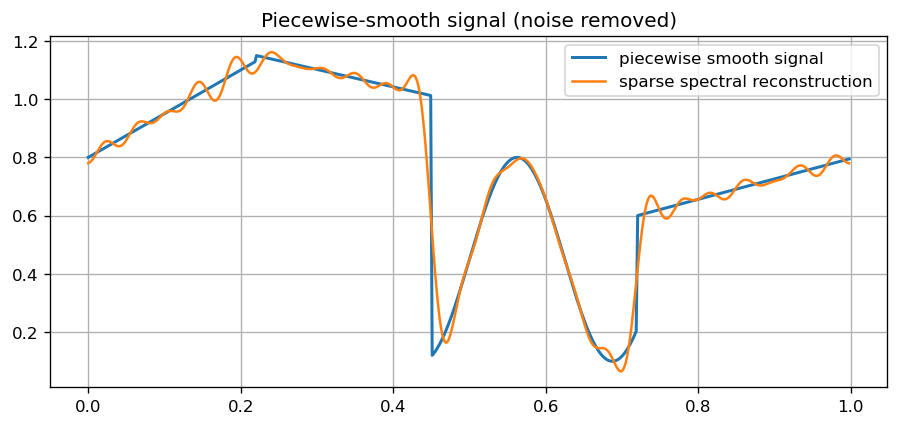

In [2]:
F = np.fft.rfft(f)
k = int(0.08*len(F))
th = np.partition(np.abs(F), -k)[-k]
Fr = F * (np.abs(F) >= th)
rec = np.fft.irfft(Fr, n=n)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(t, f, lw=1.8, label='piecewise smooth signal')
ax.plot(t, rec, lw=1.5, label='sparse spectral reconstruction')
ax.legend()
ax.set_title('Piecewise-smooth signal (noise removed)')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
